In [4]:
# Revenue optimization notebook

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.optimize import minimize

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

# Load processed daily dataset
daily = pd.read_csv("../data/processed/daily_aggregated.csv")

# Basic cleaning safeguard
daily = daily[(daily["daily_demand"] > 0) & (daily["avg_price"] > 0)]

daily.head()

,arrival_date,daily_demand,avg_price,month,day_of_week,is_weekend
0,2015-07-01,100,95.368300,7,2,0
1,2015-07-02,36,99.188611,7,3,0
2,2015-07-03,37,99.524054,7,4,0
3,2015-07-04,44,90.669091,7,5,1
4,2015-07-05,37,107.966486,7,6,1


In [5]:
from sklearn.linear_model import LinearRegression

daily["log_demand"] = np.log(daily["daily_demand"])
daily["log_price"] = np.log(daily["avg_price"])

X = daily[["log_price"]]
y = daily["log_demand"]

model = LinearRegression()
model.fit(X, y)

elasticity = model.coef_[0]

print("Estimated Elasticity:", round(elasticity, 3))

Estimated Elasticity: 0.408


In [6]:
# Define baseline values
base_demand = daily["daily_demand"].mean()
reference_price = daily["avg_price"].mean()

def demand_function(price):
    return base_demand * (price / reference_price) ** elasticity

In [7]:
def revenue_function(price):
    demand = demand_function(price[0])
    revenue = price[0] * demand
    return -revenue

In [8]:
capacity = 120
price_floor = 50
price_ceiling = 500

# Constraint: demand must not exceed capacity
def capacity_constraint(price):
    return capacity - demand_function(price[0])

In [9]:
constraints = [{"type": "ineq", "fun": capacity_constraint}]
bounds = [(price_floor, price_ceiling)]

result = minimize(
    revenue_function,
    x0=[reference_price],
    bounds=bounds,
    constraints=constraints
)

optimal_price = result.x[0]
optimal_demand = min(demand_function(optimal_price), capacity)
optimal_revenue = optimal_price * optimal_demand

print("Constrained Optimal Price:", round(optimal_price, 2))
print("Expected Demand:", round(optimal_demand, 2))
print("Expected Revenue:", round(optimal_revenue, 2))

Constrained Optimal Price: 190.96
Expected Demand: 120
Expected Revenue: 22914.81


In [10]:
constraints = [{"type": "ineq", "fun": capacity_constraint}]
bounds = [(price_floor, price_ceiling)]

result = minimize(
    revenue_function,
    x0=[reference_price],
    bounds=bounds,
    constraints=constraints
)

optimal_price = result.x[0]
optimal_demand = min(demand_function(optimal_price), capacity)
optimal_revenue = optimal_price * optimal_demand

print("Constrained Optimal Price:", round(optimal_price, 2))
print("Expected Demand:", round(optimal_demand, 2))
print("Expected Revenue:", round(optimal_revenue, 2))

Constrained Optimal Price: 190.96
Expected Demand: 120
Expected Revenue: 22914.81


In [12]:
price_range = np.linspace(price_floor, price_ceiling, 200)

revenues = []
demands = []

for p in price_range:
    d = demand_function(p)
    revenues.append(p * d)
    demands.append(d)

revenues = np.array(revenues)
demands = np.array(demands)

unconstrained_price = price_range[np.argmax(revenues)]
unconstrained_revenue = np.max(revenues)

print("Unconstrained Optimal Price:", round(unconstrained_price, 2))
print("Unconstrained Revenue:", round(unconstrained_revenue, 2))

Unconstrained Optimal Price: 500.0
Unconstrained Revenue: 88897.42


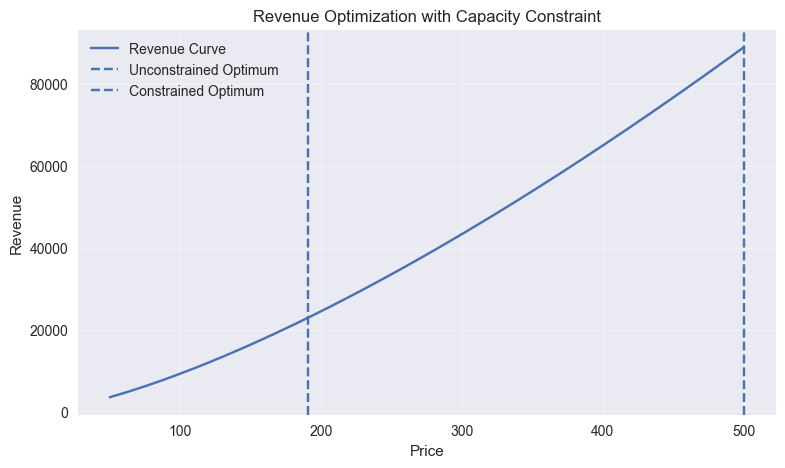

In [13]:
plt.figure(figsize=(9,5))
plt.plot(price_range, revenues, label="Revenue Curve")

plt.axvline(unconstrained_price, linestyle="--", label="Unconstrained Optimum")
plt.axvline(optimal_price, linestyle="--", label="Constrained Optimum")

plt.title("Revenue Optimization with Capacity Constraint")
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

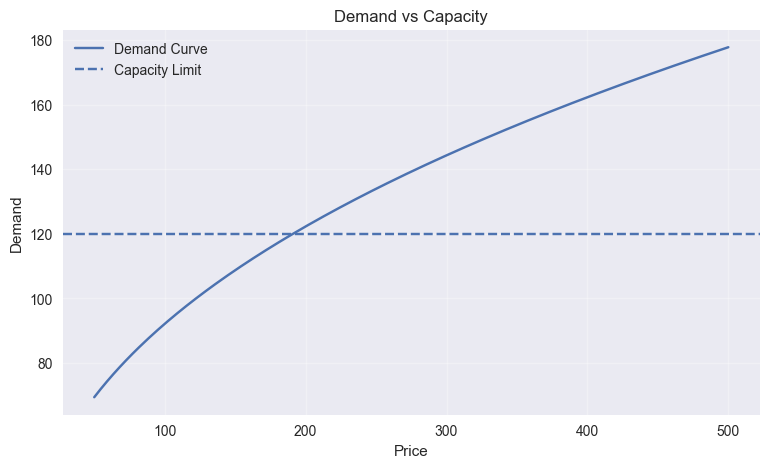

In [14]:
plt.figure(figsize=(9,5))
plt.plot(price_range, demands, label="Demand Curve")
plt.axhline(capacity, linestyle="--", label="Capacity Limit")

plt.title("Demand vs Capacity")
plt.xlabel("Price")
plt.ylabel("Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.show()